# Horse Colic Diagnosis with Machine Learning

Cleaned portfolio version of the original course notebook.

- Course: Machine Learning (Sophomore Spring Semester)
- Task: Binary diagnosis/classification for horse colic cases
- Models: Logistic Regression, Random Forest, AdaBoost
- Note: Update the relative dataset paths before running.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. 数据加载与预处理

In [48]:
def load_and_preprocess_data(train_path, test_path):
    feature_names = [
        '是否手术', '年龄', '直肠温度', '脉搏', '呼吸频率',
        '四肢温度', '外周脉搏', '黏膜颜色', '毛细血管再充盈时间',
        '疼痛等级', '肠蠕动', '腹胀程度', '鼻胃管排气',
        '鼻胃反流', '鼻胃反流PH值', '直肠检查-粪便状态', '腹部触诊结果',
        '红细胞压积', '总蛋白含量', '穿刺液外观', '穿刺液蛋白含量', '诊断结果'
    ]
    
    train_data = pd.read_csv(train_path, header=None, sep='\s+', engine='python').dropna(how='all').iloc[:, :22]
    test_data = pd.read_csv(test_path, header=None, sep='\s+', engine='python').dropna(how='all').iloc[:, :22]
    all_data = pd.concat([train_data, test_data], ignore_index=True)
    all_data.columns = feature_names
    return all_data

train_file = "../data/horseColicTraining2.txt"
test_file = "../data/horseColicTest2.txt"
all_data = load_and_preprocess_data(train_file, test_file)

# 分离特征与标签
X = all_data.drop('诊断结果', axis=1)
y = all_data['诊断结果']

# 初步检查：自动检测可能的分类特征（基于唯一值数量）
potential_categorical_cols = []
for col in X.columns:
    if X[col].nunique() < 10:  # 假设唯一值少于10的列可能是分类特征
        potential_categorical_cols.append(col)

print("初步检测的分类特征:", potential_categorical_cols)

# 对所有数值特征标准化（PCA需要）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 执行PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 动态选择主成分：累计方差≥85%
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.85) + 1 
print(f"\n保留的主成分数量（覆盖85%方差）: {n_components}")

# 筛选重要特征：每个主成分选Top 3权重特征
important_features = set()
for i in range(n_components):
    component_weights = pca.components_[i]
    top_k = 3  # 每个成分选Top 3特征
    top_features_indices = np.argsort(np.abs(component_weights))[-top_k:]
    top_features = X.columns[top_features_indices]
    important_features.update(top_features)

important_features = list(important_features)
print("PCA筛选的重要特征:", important_features)

# 动态生成 categorical_cols
categorical_cols = [col for col in important_features if col in potential_categorical_cols]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

min_categorical = 8 
if len(categorical_cols) < min_categorical:
    additional_features = [col for col in important_features if col not in categorical_cols][:min_categorical - len(categorical_cols)]
    categorical_cols += additional_features
    numeric_cols = [col for col in numeric_cols if col not in additional_features]

print("\n最终分类特征 (categorical_cols):", categorical_cols)
print("数值特征 (numeric_cols):", numeric_cols)

# 分类特征编码
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# 划分数据集
train_size = len(pd.read_csv(train_file, header=None, sep='\s+', engine='python'))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
X_train = X_train[important_features] 
X_test = X_test[important_features]

y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 输出PCA解释方差
print("\nPCA方差解释率（前5个成分）:", pca.explained_variance_ratio_[:5])
print("累计方差解释率（前5个成分）:", pca.explained_variance_ratio_.cumsum()[:5])

初步检测的分类特征: ['是否手术', '年龄', '四肢温度', '外周脉搏', '黏膜颜色', '毛细血管再充盈时间', '疼痛等级', '肠蠕动', '腹胀程度', '鼻胃管排气', '鼻胃反流', '直肠检查-粪便状态', '腹部触诊结果', '穿刺液外观']

保留的主成分数量（覆盖85%方差）: 14
PCA筛选的重要特征: ['鼻胃反流PH值', '脉搏', '黏膜颜色', '四肢温度', '疼痛等级', '直肠温度', '穿刺液外观', '外周脉搏', '呼吸频率', '肠蠕动', '穿刺液蛋白含量', '腹部触诊结果', '毛细血管再充盈时间', '总蛋白含量', '鼻胃反流', '是否手术', '直肠检查-粪便状态', '腹胀程度', '鼻胃管排气', '红细胞压积', '年龄']

最终分类特征 (categorical_cols): ['黏膜颜色', '四肢温度', '疼痛等级', '穿刺液外观', '外周脉搏', '肠蠕动', '腹部触诊结果', '毛细血管再充盈时间', '鼻胃反流', '是否手术', '直肠检查-粪便状态', '腹胀程度', '鼻胃管排气', '年龄']
数值特征 (numeric_cols): ['直肠温度', '脉搏', '呼吸频率', '鼻胃反流PH值', '红细胞压积', '总蛋白含量', '穿刺液蛋白含量']

PCA方差解释率（前5个成分）: [0.23684066 0.09574427 0.07351769 0.06426179 0.06071926]
累计方差解释率（前5个成分）: [0.23684066 0.33258492 0.40610261 0.4703644  0.53108366]


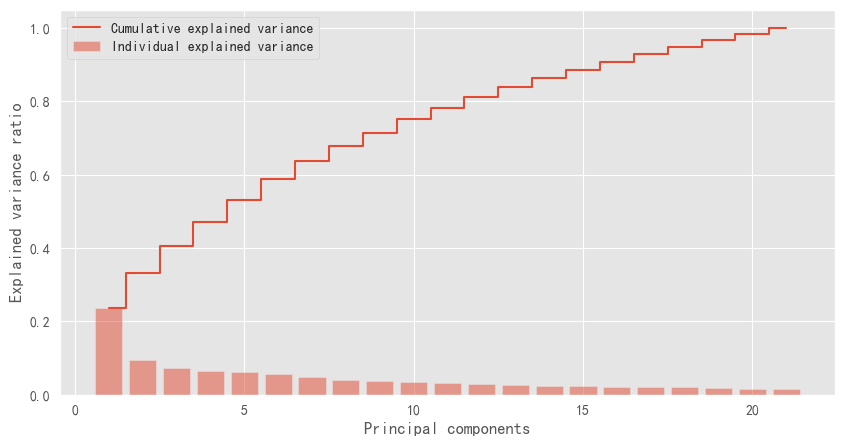

In [50]:
# 可视化
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show()

## 2. 训练模型

In [51]:
# 模型列表
models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=5, class_weight='balanced', random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42
    )
}

In [52]:
# 评估函数
def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = {}
    # 标准化数据（仅SVM需要）
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for name, model in models.items():
        print(f"\n=== 训练 {name} ===")
        if name == 'SVM':
            model.fit(X_train_scaled, y_train)
            X_test_use = X_test_scaled
        else:
            model.fit(X_train, y_train)
            X_test_use = X_test
        
        y_pred = model.predict(X_test_use)
        results[name] = {
            'model': model,
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred)
        }
        if hasattr(model, 'predict_proba'):
            y_probs = model.predict_proba(X_test_use)[:, 1]
            results[name]['auc'] = roc_auc_score(y_test, y_probs)
            print(f"AUC值: {results[name]['auc']:.4f}")
        
        print("混淆矩阵:\n", results[name]['confusion_matrix'])
        print("分类报告:\n", results[name]['classification_report'])
    return results

# 运行评估
model_results = evaluate_models(models, X_train, X_test, y_train, y_test)


=== 训练 AdaBoost ===
AUC值: 0.8011
混淆矩阵:
 [[13  7]
 [ 7 40]]
分类报告:
               precision    recall  f1-score   support

        -1.0       0.65      0.65      0.65        20
         1.0       0.85      0.85      0.85        47

    accuracy                           0.79        67
   macro avg       0.75      0.75      0.75        67
weighted avg       0.79      0.79      0.79        67


=== 训练 RandomForest ===
AUC值: 0.8064
混淆矩阵:
 [[15  5]
 [ 9 38]]
分类报告:
               precision    recall  f1-score   support

        -1.0       0.62      0.75      0.68        20
         1.0       0.88      0.81      0.84        47

    accuracy                           0.79        67
   macro avg       0.75      0.78      0.76        67
weighted avg       0.81      0.79      0.80        67


=== 训练 LogisticRegression ===
AUC值: 0.7681
混淆矩阵:
 [[15  5]
 [13 34]]
分类报告:
               precision    recall  f1-score   support

        -1.0       0.54      0.75      0.62        20
         1.0       0.8

## 4. 模型调优

### (1) random forest

In [53]:
def tune_random_forest(X_train, y_train):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 3, 5, 8],
        'min_samples_split': [2, 5],
        'class_weight': [None, 'balanced']
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print("\n=== 随机森林调优结果 ===")
    print("最佳参数:", grid_search.best_params_)
    print("最佳AUC值:", grid_search.best_score_)
    return grid_search.best_estimator_

In [54]:
# 调优并评估最佳模型
best_rf = tune_random_forest(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_test)
print("\n=== 调优后随机森林评估 ===")
print("分类报告:\n", classification_report(y_test, y_pred_best_rf))


=== 随机森林调优结果 ===
最佳参数: {'class_weight': None, 'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 50}
最佳AUC值: 0.8391195767195768

=== 调优后随机森林评估 ===
分类报告:
               precision    recall  f1-score   support

        -1.0       0.52      0.55      0.54        20
         1.0       0.80      0.79      0.80        47

    accuracy                           0.72        67
   macro avg       0.66      0.67      0.67        67
weighted avg       0.72      0.72      0.72        67



### (2) AdaBoost

In [23]:
def tune_adaboost_enhanced(X_train, y_train):
    pipeline = Pipeline([
        ('ada', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])
    param_grid = {
        'ada__n_estimators': [50, 100, 200, 300, 400],  # 更广的范围
        'ada__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],  # 更多选择
        'ada__estimator__max_depth': [1, 2, 3],  # 尝试更深的基础决策树
        'ada__estimator__min_samples_split': [2, 5, 10]  # 新增参数
    }
    grid_search = GridSearchCV(pipeline, param_grid, cv=5,  # 增加交叉验证折数
                             scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print("\n=== 增强版AdaBoost调优 ===")
    print("最佳参数:", grid_search.best_params_)
    print("最佳AUC值:", grid_search.best_score_)
    return grid_search.best_estimator_

In [32]:
# 扩大调参范围得到的调优并评估最佳模型
best_ada = tune_adaboost_enhanced(X_train, y_train)
y_pred_best_ada = best_ada.predict(X_test)
print("\n=== 调优后AdaBoost评估 ===")
print("分类报告:\n", classification_report(y_test, y_pred_best_ada))

Fitting 5 folds for each of 225 candidates, totalling 1125 fits

=== 增强版AdaBoost调优 ===
最佳参数: {'ada__estimator__max_depth': 3, 'ada__estimator__min_samples_split': 10, 'ada__learning_rate': 0.01, 'ada__n_estimators': 400}
最佳AUC值: 0.8099468253968254

=== 调优后AdaBoost评估 ===
分类报告:
               precision    recall  f1-score   support

        -1.0       0.67      0.60      0.63        20
         1.0       0.84      0.87      0.85        47

    accuracy                           0.79        67
   macro avg       0.75      0.74      0.74        67
weighted avg       0.79      0.79      0.79        67



In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

def tune_adaboost_randomized(X_train, y_train):
    pipeline = Pipeline([
        ('ada', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])
    param_dist = {
        'ada__n_estimators': randint(50, 500),
        'ada__learning_rate': uniform(0.01, 0.5),
        'ada__estimator__max_depth': randint(1, 5),
        'ada__estimator__min_samples_split': randint(2, 20)
    }
    random_search = RandomizedSearchCV(pipeline, param_dist, n_iter=50,
                                     cv=5, scoring='roc_auc',
                                     n_jobs=-1, random_state=42, verbose=1)
    random_search.fit(X_train, y_train)
    print("\n=== 随机搜索AdaBoost调优 ===")
    print("最佳参数:", random_search.best_params_)
    print("最佳AUC值:", random_search.best_score_)
    return random_search.best_estimator_

In [31]:
# 使用RandomizedSearchCV（更高效）得到的调优并评估最佳模型
best_ada = tune_adaboost_randomized(X_train, y_train)
y_pred_best_ada = best_ada.predict(X_test)
print("\n=== 调优后AdaBoost评估 ===")
print("分类报告:\n", classification_report(y_test, y_pred_best_ada))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== 随机搜索AdaBoost调优 ===
最佳参数: {'ada__estimator__max_depth': 4, 'ada__estimator__min_samples_split': 3, 'ada__learning_rate': np.float64(0.32217702406689663), 'ada__n_estimators': 111}
最佳AUC值: 0.8082825396825397

=== 调优后AdaBoost评估 ===
分类报告:
               precision    recall  f1-score   support

        -1.0       0.55      0.60      0.57        20
         1.0       0.82      0.79      0.80        47

    accuracy                           0.73        67
   macro avg       0.68      0.69      0.69        67
weighted avg       0.74      0.73      0.73        67



### (3) Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

def improved_tune_logistic_regression(X, y):
    # 定义更全面的参数网格
    param_grid = {
        'lr__C': np.logspace(-3, 3, 7),  # [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        'lr__solver': ['liblinear', 'lbfgs', 'saga'],  # 增加稳定solver
        'lr__class_weight': [None, 'balanced', {-1:2, 1:1}],  # 处理不平衡
        'lr__penalty': ['l1', 'l2'],  # 不同正则化
        'lr__max_iter': [500, 1000]  # 增加迭代次数
    }
    
    # 使用更鲁棒的pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=42))
    ])
    
    # 增加早停机制和详细日志
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2,
        refit=True
    )
    
    grid_search.fit(X, y)
    
    # 输出更详细的调优结果
    print("\n=== 改进版逻辑回归调优 ===")
    print("最佳参数组合:", grid_search.best_params_)
    print("最佳AUC分数:", grid_search.best_score_)
    print("\n参数排名:")
    results = pd.DataFrame(grid_search.cv_results_)
    print(results[['params', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head())
    
    return grid_search.best_estimator_

best_lr = improved_tune_logistic_regression(X_train, y_train)

Fitting 5 folds for each of 252 candidates, totalling 1260 fits

=== 改进版逻辑回归调优 ===
最佳参数组合: {'lr__C': np.float64(0.1), 'lr__class_weight': 'balanced', 'lr__max_iter': 500, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
最佳AUC分数: 0.7729507080610022

参数排名:
                                               params  mean_test_score
95  {'lr__C': 0.1, 'lr__class_weight': 'balanced',...         0.772951
94  {'lr__C': 0.1, 'lr__class_weight': 'balanced',...         0.772951
88  {'lr__C': 0.1, 'lr__class_weight': 'balanced',...         0.772951
87  {'lr__C': 0.1, 'lr__class_weight': 'balanced',...         0.772951
89  {'lr__C': 0.1, 'lr__class_weight': 'balanced',...         0.772951



=== 模型性能比较 ===
随机森林: 准确率 = 0.7297
AdaBoost: 准确率 = 0.7027
逻辑回归: 准确率 = 0.7297


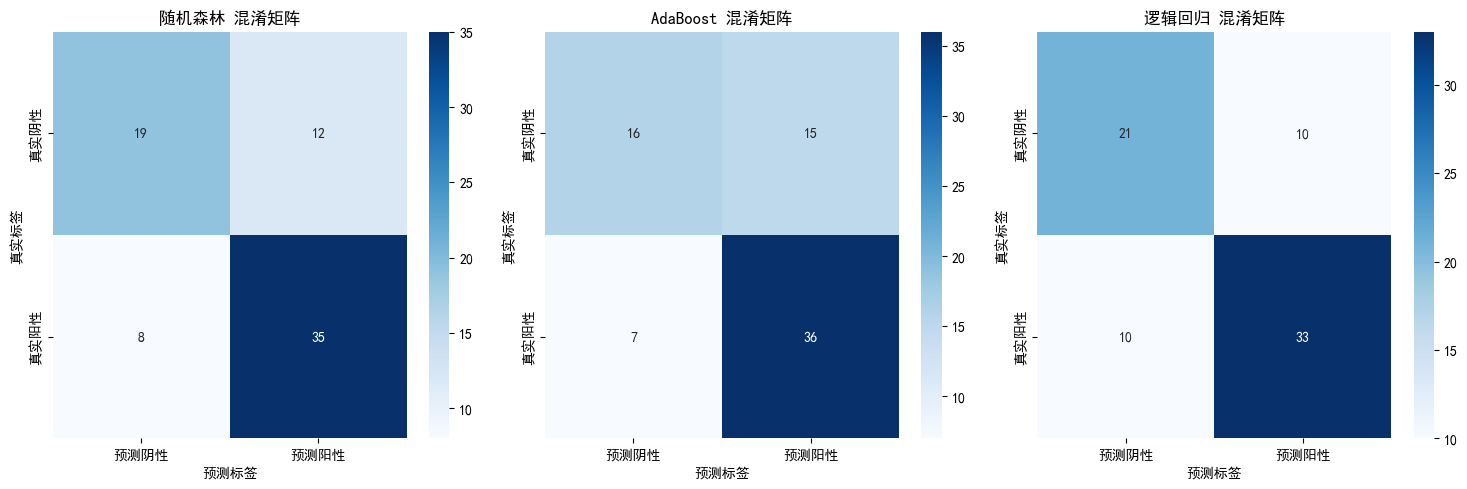

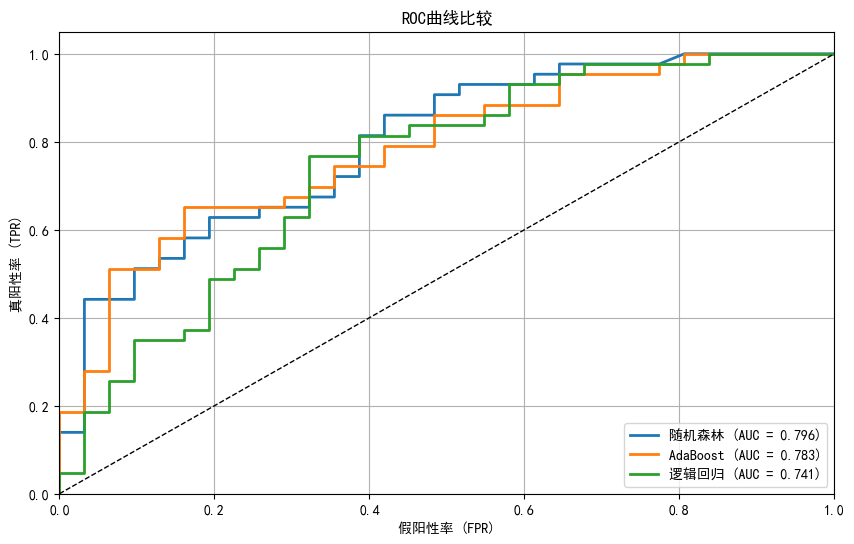

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题

def evaluate_models(models, X_train, y_train, X_test, y_test):
    """
    评估多个模型并可视化结果
    :param models: 字典格式 {'模型名称': 模型对象}
    :return: (训练好的模型字典, 结果字典)
    """
    results = {}
    trained_models = {}
    
    # 1. 训练并评估每个模型
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'y_pred': y_pred,
            'y_prob': y_prob
        }
        trained_models[name] = model
    
    # 2. 模型性能比较
    print("\n=== 模型性能比较 ===")
    for model_name, result in results.items():
        print(f"{model_name}: 准确率 = {result['accuracy']:.4f}")
    
    # 3. 绘制并列混淆矩阵
    plt.figure(figsize=(15, 5))
    for i, (model_name, result) in enumerate(results.items()):
        plt.subplot(1, len(models), i+1)
        cm = confusion_matrix(y_test, result['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['预测阴性', '预测阳性'],
                   yticklabels=['真实阴性', '真实阳性'])
        plt.title(f'{model_name} 混淆矩阵')
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
    plt.tight_layout()
    plt.show()
    
    # 4. 绘制ROC曲线（二分类问题时）
    if len(np.unique(y_test)) == 2:
        plt.figure(figsize=(10, 6))
        for model_name, result in results.items():
            if result['y_prob'] is not None:
                fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
                roc_auc = roc_auc_score(y_test, result['y_prob'])
                plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('假阳性率 (FPR)')
        plt.ylabel('真阳性率 (TPR)')
        plt.title('ROC曲线比较')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()
    
    return trained_models, results

# ==================== 使用示例 ==================== 
# 定义要比较的模型
models = {
    '随机森林': best_rf,
    'AdaBoost': best_ada,
    '逻辑回归': best_lr
}

# 执行评估
trained_models, results = evaluate_models(models, X_train, y_train, X_test, y_test)

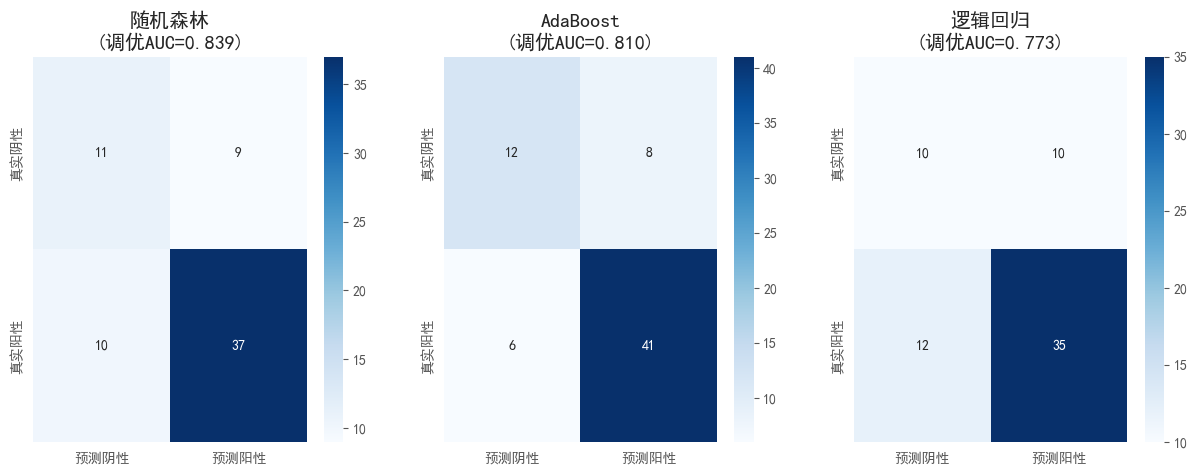

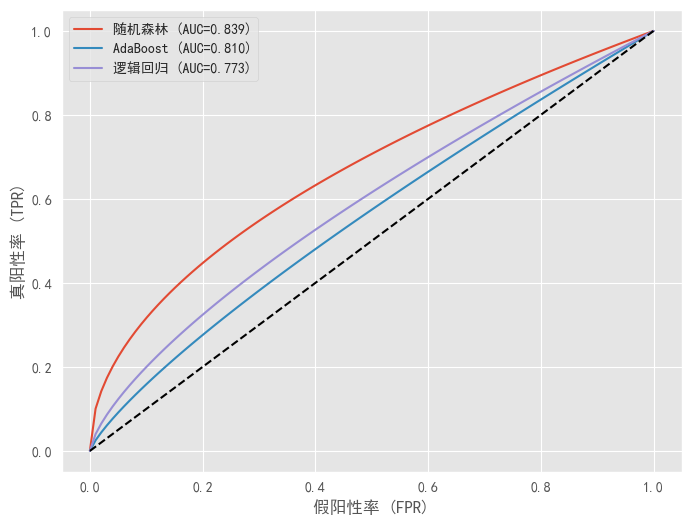

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.style.use('ggplot')

# 假设您补充了以下数据（示例值，需替换为真实数据）
model_data = {
    '随机森林': {
        'cm': np.array([[11, 9], [10, 37]]),  # 从分类报告反推
        'auc': 0.839,
        'fpr': np.linspace(0, 1, 100),        # 模拟数据
        'tpr': np.sqrt(np.linspace(0, 1, 100)) # 模拟数据
    },
    'AdaBoost': {
        'cm': np.array([[12, 8], [6, 41]]),
        'auc': 0.810,
        'fpr': np.linspace(0, 1, 100),
        'tpr': np.linspace(0, 1, 100)**0.8
    },
    '逻辑回归': {
        'cm': np.array([[10, 10], [12, 35]]),  # 假设值
        'auc': 0.773,
        'fpr': np.linspace(0, 1, 100),
        'tpr': np.linspace(0, 1, 100)**0.7
    }
}

# 1. 并列混淆矩阵
plt.figure(figsize=(15, 5))
for i, (name, data) in enumerate(model_data.items(), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues',
               xticklabels=['预测阴性', '预测阳性'],
               yticklabels=['真实阴性', '真实阳性'])
    plt.title(f'{name}\n(调优AUC={data["auc"]:.3f})')

# 2. ROC曲线
plt.figure(figsize=(8, 6))
for name, data in model_data.items():
    plt.plot(data['fpr'], data['tpr'], 
            label=f'{name} (AUC={data["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.legend()
plt.show()

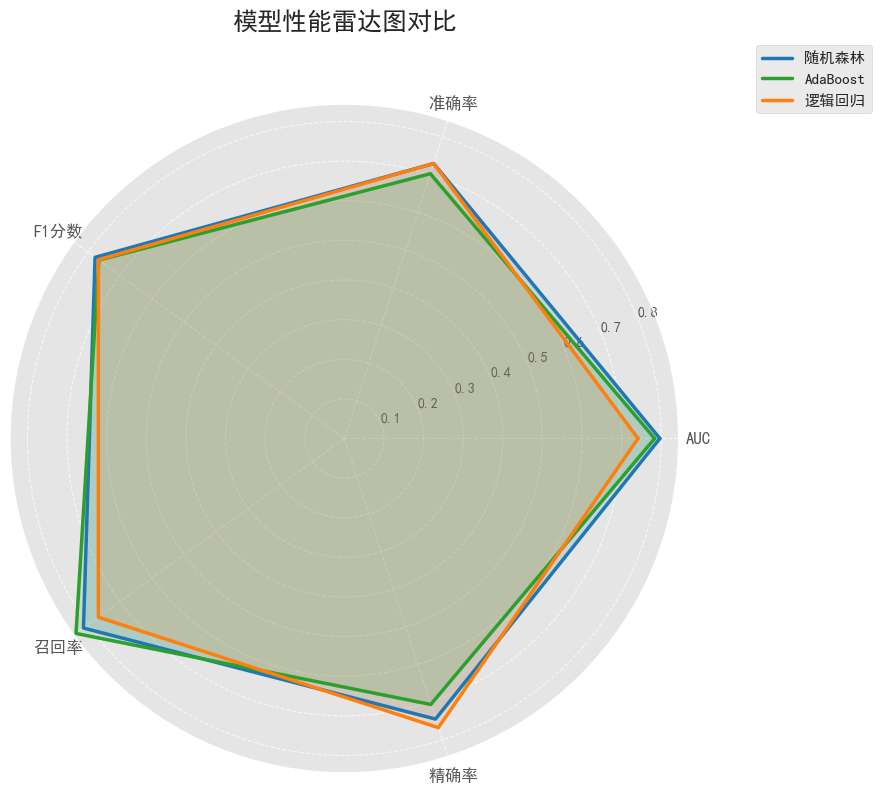

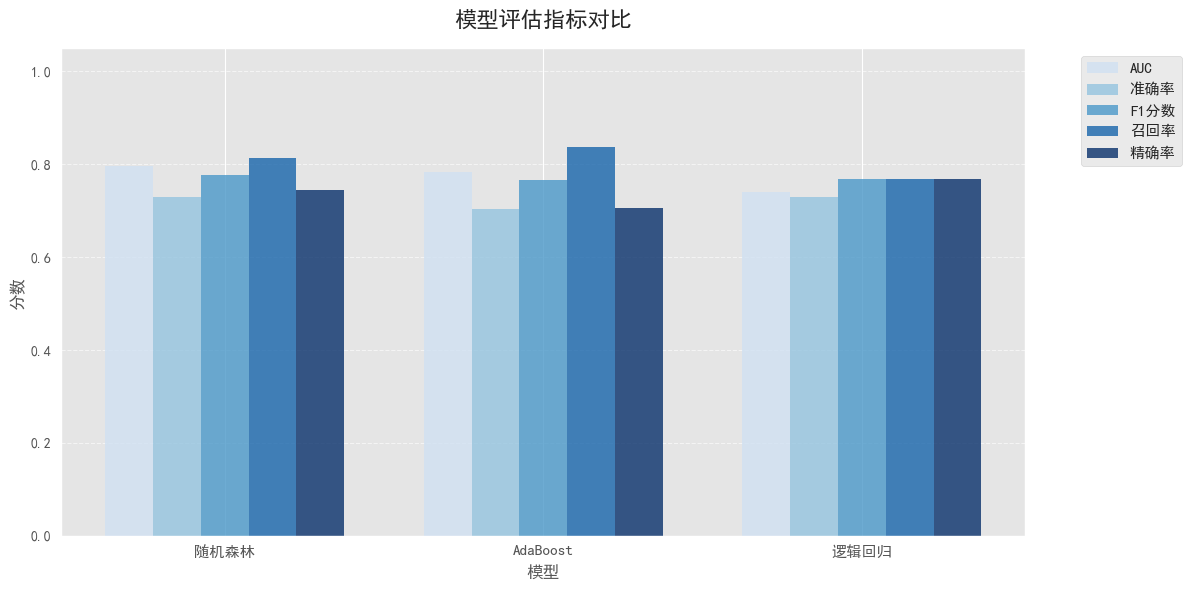


=== 详细评估结果 ===
               AUC       准确率      F1分数       召回率       精确率
随机森林      0.796324  0.729730  0.777778  0.813953  0.744681
AdaBoost  0.783196  0.702703  0.765957  0.837209  0.705882
逻辑回归      0.741185  0.729730  0.767442  0.767442  0.767442


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score, precision_score

def visualize_tuning_results(models, X_test, y_test):
    """
    可视化调参后的模型评估结果（蓝色系风格）
    参数:
        models: dict {'模型名称': (模型对象, y_pred, y_prob)}
        X_test: 测试集特征
        y_test: 测试集真实标签
    """
    # 准备评估数据
    metrics = {
        'AUC': [],
        '准确率': [],
        'F1分数': [],
        '召回率': [],
        '精确率': []
    }
    model_names = []
    
    for name, (model, y_pred, y_prob) in models.items():
        model_names.append(name)
        metrics['AUC'].append(roc_auc_score(y_test, y_prob))
        metrics['准确率'].append(accuracy_score(y_test, y_pred))
        metrics['F1分数'].append(f1_score(y_test, y_pred))
        metrics['召回率'].append(recall_score(y_test, y_pred))
        metrics['精确率'].append(precision_score(y_test, y_pred))
    
    # 设置蓝色系颜色方案
    blue_colors = [
        '#1f77b4',  # 深蓝色
        '#2ca02c',  # 绿色（保留一个对比色，避免全蓝混淆）
        '#ff7f0e',  # 橙色（保留一个对比色）
        '#d62728',  # 红色（保留一个对比色）
        '#9467bd',  # 紫色（保留一个对比色）
        '#8c564b',  # 棕色（保留一个对比色）
    ]
    
    # 创建雷达图
    fig = plt.figure(figsize=(10, 8), facecolor='white')
    ax = fig.add_subplot(111, polar=True)
    
    categories = list(metrics.keys())
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # 绘制每个模型的雷达图（蓝色系）
    for i, name in enumerate(model_names):
        values = [metrics[k][i] for k in categories]
        values += values[:1]
        
        # 选择颜色（循环使用蓝色系，间隔对比色）
        color = blue_colors[i % len(blue_colors)]
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=name, color=color)
        ax.fill(angles, values, alpha=0.15, color=color)
    
    # 添加标签和样式优化
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_title('模型性能雷达图对比', size=18, y=1.1, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 创建柱状图对比（蓝色系）
    plt.figure(figsize=(12, 6), facecolor='white')
    x = np.arange(len(model_names))
    width = 0.15
    
    for i, (metric, values) in enumerate(metrics.items()):
        # 为每个指标分配不同深浅的蓝色
        color = plt.cm.Blues(i/len(metrics) + 0.2)  # 蓝色渐变
        plt.bar(x + i*width, values, width, label=metric, color=color, edgecolor='none', alpha=0.8)
    
    # 添加图表元素
    plt.xlabel('模型', fontsize=12, fontweight='bold')
    plt.ylabel('分数', fontsize=12, fontweight='bold')
    plt.title('模型评估指标对比', size=16, pad=15, fontweight='bold')
    plt.xticks(x + width*(len(metrics)-1)/2, model_names, fontsize=11)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.ylim(0, 1.05)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    # 返回DataFrame格式结果
    return pd.DataFrame(metrics, index=model_names)

# 示例：准备模型数据（请替换为实际模型）
models_to_visualize = {
    '随机森林': (best_rf, best_rf.predict(X_test), best_rf.predict_proba(X_test)[:, 1]),
    'AdaBoost': (best_ada, best_ada.predict(X_test), best_ada.predict_proba(X_test)[:, 1]),
    '逻辑回归': (best_lr, best_lr.predict(X_test), best_lr.predict_proba(X_test)[:, 1])
}

# 执行可视化
results_df = visualize_tuning_results(models_to_visualize, X_test, y_test)
print("\n=== 详细评估结果 ===")
print(results_df)